In [1]:
import ast 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset


#Load the dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# data cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\abbes\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_sp = df[df['job_country'] == 'Spain']

In [4]:
df_skills = df_sp.explode('job_skills')
df_skills[['job_title', 'job_skills']]

,job_title,job_skills
115,Azure Big Data Engineer,scala
115,Azure Big Data Engineer,azure
124,DATA SCIENTIST,sql
124,DATA SCIENTIST,python
124,DATA SCIENTIST,r
...,...,...
785620,Business Intelligence and Data Management Tech...,r
785620,Business Intelligence and Data Management Tech...,java
785620,Business Intelligence and Data Management Tech...,cognos
785620,Business Intelligence and Data Management Tech...,tableau


In [ ]:
df_skills_count = df_skills.groupby(['job_skills' , 'job_title_short']).size() 
df_skills_count = df_skills_count.reset_index(name='skill count')
df_skills_count = df_skills_count.sort_values(by='skill count', ascending=False)
df_skills_count

,job_skills,job_title_short,skill count
987,python,Data Engineer,3827
988,python,Data Scientist,3804
1249,sql,Data Engineer,3765
1248,sql,Data Analyst,2595
1250,sql,Data Scientist,2493
...,...,...,...
358,f#,Software Engineer,1
1487,webex,Data Analyst,1
1486,webex,Business Analyst,1
1485,watson,Machine Learning Engineer,1


In [14]:
job_titles = df_skills_count['job_title_short'].unique().tolist()
job_titles = sorted(job_titles[:3]) # Select the first 3 job titles for visualization
job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

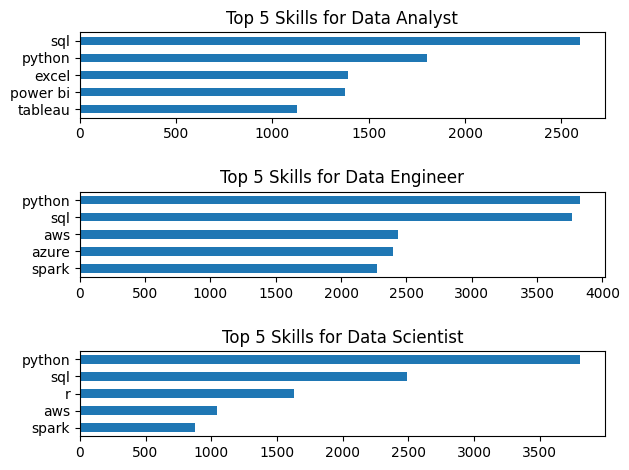

In [32]:
fig , ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='skill count', ax=ax[i], legend=False)
    ax[i].set_title(f'Top 5 Skills for {job_title}')
    ax[i].invert_yaxis()  # Invert y-axis to have the highest value on top
    ax[i].set_ylabel('')


    ax[i].legend().set_visible(False)

fig.tight_layout(h_pad=2.0)  # Adjust the layout to prevent overlap
plt.show()

In [24]:
df_job_total = df_sp['job_title_short'].value_counts().reset_index(name='jobs total')
df_job_total

,job_title_short,jobs total
0,Data Engineer,6740
1,Data Scientist,5598
2,Data Analyst,5177
3,Software Engineer,1576
4,Business Analyst,1505
5,Senior Data Engineer,1375
6,Senior Data Scientist,1346
7,Senior Data Analyst,616
8,Machine Learning Engineer,600
9,Cloud Engineer,567


In [27]:
df_skills_perc =pd.merge(df_skills_count , df_job_total , how='left' , on = 'job_title_short')
df_skills_perc['skill percentage'] = (df_skills_perc['skill count'] / df_skills_perc['jobs total']) * 100
df_skills_perc

,job_skills,job_title_short,skill count,jobs total,skill percentage
0,python,Data Engineer,3827,6740,56.780415
1,python,Data Scientist,3804,5598,67.952840
2,sql,Data Engineer,3765,6740,55.860534
3,sql,Data Analyst,2595,5177,50.125555
4,sql,Data Scientist,2493,5598,44.533762
...,...,...,...,...,...
1530,f#,Software Engineer,1,1576,0.063452
1531,webex,Data Analyst,1,5177,0.019316
1532,webex,Business Analyst,1,1505,0.066445
1533,watson,Machine Learning Engineer,1,600,0.166667


In [22]:
df_skills_count 

,job_skills,job_title_short,skill count
987,python,Data Engineer,3827
988,python,Data Scientist,3804
1249,sql,Data Engineer,3765
1248,sql,Data Analyst,2595
1250,sql,Data Scientist,2493
...,...,...,...
358,f#,Software Engineer,1
1487,webex,Data Analyst,1
1486,webex,Business Analyst,1
1485,watson,Machine Learning Engineer,1


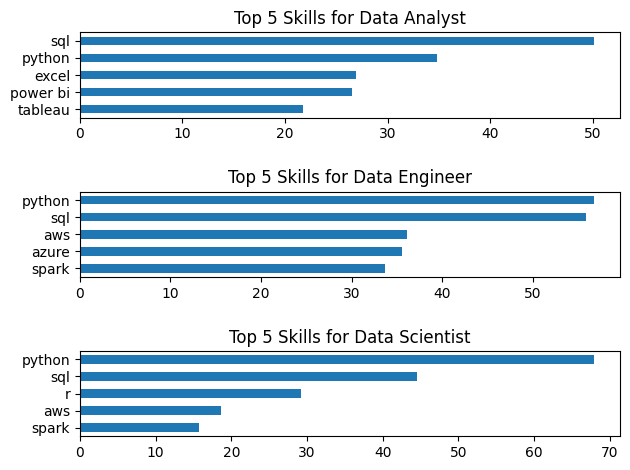

In [28]:
fig , ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='skill percentage', ax=ax[i], legend=False)
    ax[i].set_title(f'Top 5 Skills for {job_title}')
    ax[i].invert_yaxis()  # Invert y-axis to have the highest value on top
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)

fig.tight_layout(h_pad=2.0)  # Adjust the layout to prevent overlap
plt.show()